In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score

In [32]:
data = pd.read_csv('HR_Attrition.csv')
display(data.head(10))
print(f'No. of rows: {data.shape[0]}, No. of columns: {data.shape[1]}')

att_counts = data['Attrition'].value_counts()
att_rate = data['Attrition'].value_counts(normalize=True) * 100

print(f"\nAttrition Counts:\n{att_counts}")
print(f"\nAttrition Rate (%):\n{att_rate.round(2)}")

num_cols = data.select_dtypes(include=['number']).columns
cat_cols = data.select_dtypes(include=['object']).columns
print(f"\nNumeric Columns: {len(num_cols)}, Categorical Columns: {len(cat_cols)}")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


No. of rows: 1470, No. of columns: 35

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate (%):
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

Numeric Columns: 26, Categorical Columns: 9


The overall attrition rate for the company is approximately 16.12%. This means that our dataset is highly imbalanced.

In [33]:
data = data.dropna()  
data = data.drop_duplicates()

data_clean = data.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1)

data_clean['Attrition'] = data_clean['Attrition'].map({'Yes' : 1, "No" : 0})

X = data_clean.drop('Attrition', axis=1)
y = data_clean['Attrition']

X_encoded = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

In [34]:
print("Attrition by Department")
dept_att = data_clean.groupby('Department')['Attrition'].mean() * 100
print(dept_att.sort_values(ascending=False))

print("\nAttrition by Job Role")
role_att = data_clean.groupby('JobRole')['Attrition'].mean() * 100
print(role_att.sort_values(ascending=False))

print("\nIncome vs Attrition")
income_att = data_clean.groupby('Attrition')['MonthlyIncome'].mean()
print(f"Average Income (Stayed): ${income_att[0]:.2f}")
print(f"Average Income (Left): ${income_att[1]:.2f}")

print("\nAttrition by Work-Life Balance (1=Worst, 4=Best)")
wlb_att = data_clean.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print(wlb_att)

print("\nAttrition by Years at Company")
years_att = data_clean.groupby('YearsAtCompany')['Attrition'].mean() * 100
print(years_att.head())

Attrition by Department
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

Attrition by Job Role
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

Income vs Attrition
Average Income (Stayed): $6832.74
Average Income (Left): $4787.09

Attrition by Work-Life Balance (1=Worst, 4=Best)
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

Attrition by Years at Company
YearsAtCompany
0    36.363636
1    34.502924
2    21.259843
3    15.625000
4    17.272727
Name: Attrition, dtype: float64


From the Attrition data above, we find that:-
1. Department: Sales & HR show the most attrition rates, with 20.62% and 19.04% respectively. Our main focus should be on these departments.  

2. Job Role: Sales Representatives have the highest attrition rate here with a massive 39.75% attrition. Sales department requires immediate attention and takes top priority.

3. Income: The avg. income of employees who stayed is approximately $2000 higher than the avg. income of employees who left. There needs to be proper compensation provided here.

4. Work-Life Balance: Employees who reported a bad work-life balance (1) are twice as likely to leave than employees who reported a good work-life balance (3). Overall work-life balance needs to be improved.

5. Years at Company: Employees in their first and second years show huge spikes in resignations, whereas crossing the 3-4 years threshold reduces this spike drastically. Employee retention is a key factor here.  

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
gb_model = GradientBoostingClassifier(random_state = 42)

log_reg.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [36]:
models = {"Logistic Regression": log_reg, "RandomForestClassifier": rf_model, "GradientBoostingClassifier": gb_model}
results_data = []

print("\n1. Model Evaluation Metrics")
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n[{name}]")
    print(confusion_matrix(y_test, y_pred))
    
    results_data.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

print("\n2. Model Comparison Table")
comp = pd.DataFrame(results_data)
display(comp.round(3))

print("\n3. Top 10 Features Driving Attrition")

best_model = models["Logistic Regression"]
coefficients = best_model.coef_[0]
feats = X_train.columns

# 3. Build a DataFrame
feats_imp = pd.DataFrame({
    'Feature': feats,
    'Importance': np.abs(coefficients), 
    'Direction': np.where(coefficients > 0, 'LEAVE', 'STAY')        
})

feats_imp = feats_imp.sort_values(by='Importance', ascending=False)
display(feats_imp.head(10))


1. Model Evaluation Metrics

[Logistic Regression]
[[190  57]
 [ 18  29]]

[RandomForestClassifier]
[[242   5]
 [ 44   3]]

[GradientBoostingClassifier]
[[239   8]
 [ 38   9]]

2. Model Comparison Table


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.337,0.617,0.436,0.796
1,RandomForestClassifier,0.375,0.064,0.109,0.767
2,GradientBoostingClassifier,0.529,0.191,0.281,0.798



3. Top 10 Features Driving Attrition


,Feature,Importance,Direction
35,JobRole_Laboratory Technician,0.798465,LEAVE
44,OverTime_Yes,0.768793,LEAVE
24,BusinessTravel_Travel_Frequently,0.717318,LEAVE
8,JobLevel,0.657898,LEAVE
17,TotalWorkingYears,0.651826,STAY
41,JobRole_Sales Representative,0.560216,LEAVE
25,BusinessTravel_Travel_Rarely,0.509415,LEAVE
28,EducationField_Life Sciences,0.499144,STAY
22,YearsSinceLastPromotion,0.498347,LEAVE
27,Department_Sales,0.472967,LEAVE


Logistic Regression is the best model here because of significantly higher Recall. This means it more accurately predicts which employees are going to leave as compared to the other models.

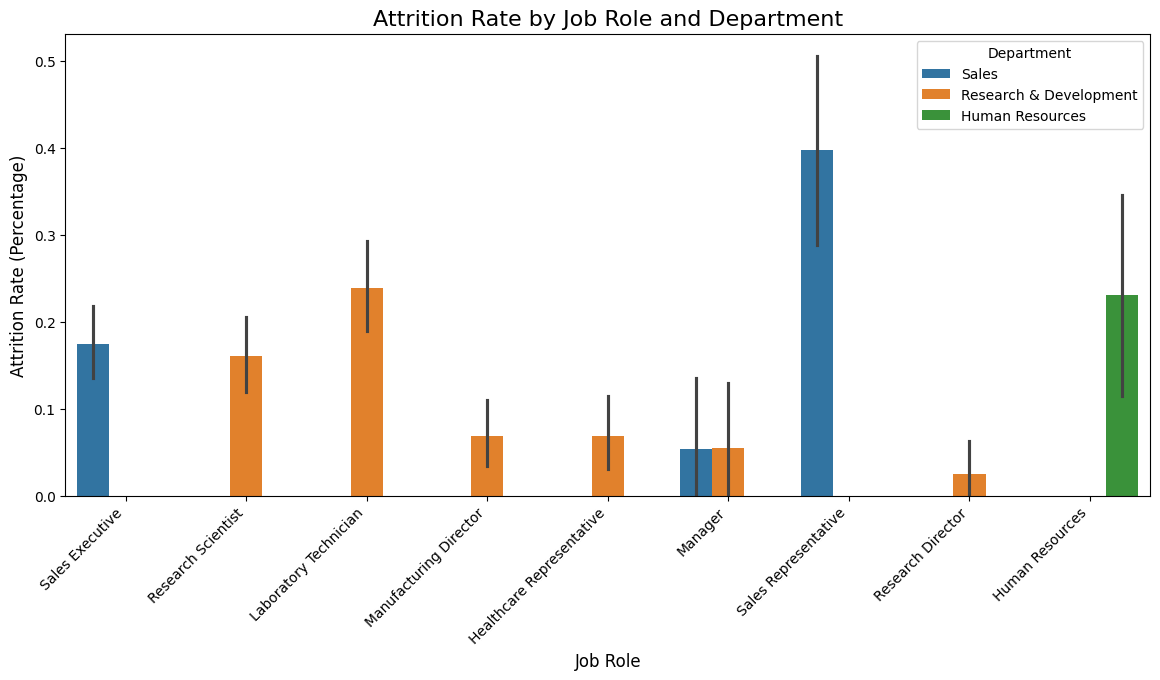

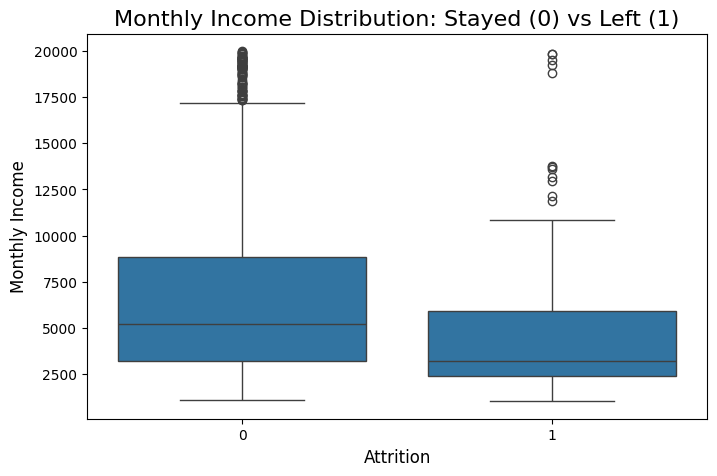

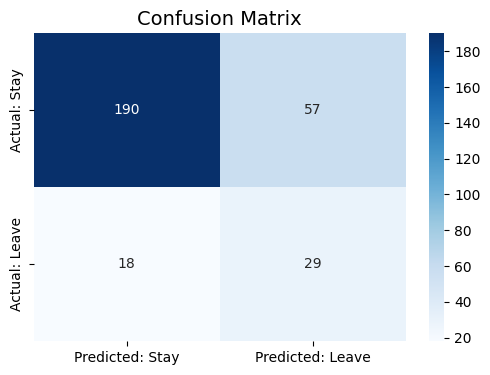

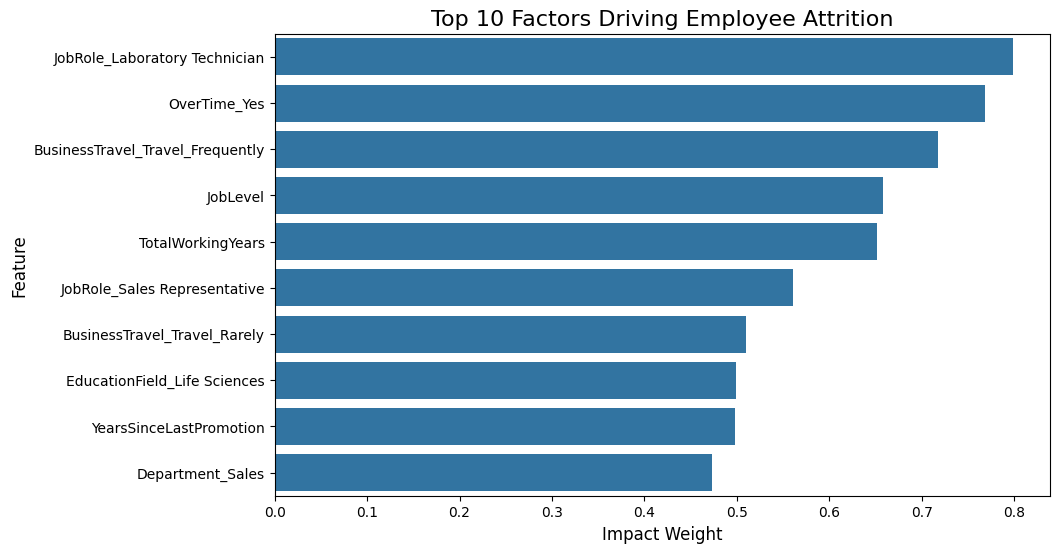

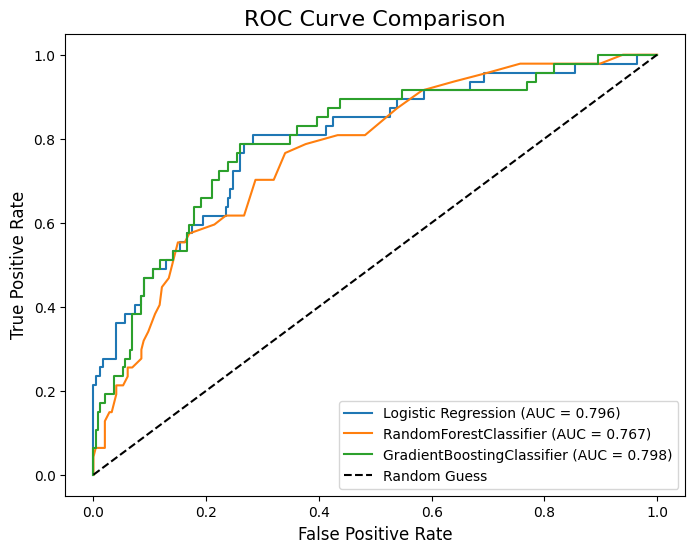

In [37]:
plt.figure(figsize=(14, 6))
sns.barplot(x='JobRole', y='Attrition', hue='Department', data=data_clean)
plt.title('Attrition Rate by Job Role and Department', fontsize=16)
plt.ylabel('Attrition Rate (Percentage)', fontsize=12)
plt.xlabel('Job Role', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Department')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data_clean)
plt.title('Monthly Income Distribution: Stayed (0) vs Left (1)', fontsize=16)
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Monthly Income', fontsize=12)
plt.show()

best_model = models["Logistic Regression"]
y_pred= best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Stay', 'Predicted: Leave'], 
            yticklabels=['Actual: Stay', 'Actual: Leave'])
plt.title('Confusion Matrix', fontsize=14)
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feats_imp.head(10))
plt.title('Top 10 Factors Driving Employee Attrition', fontsize=16)
plt.xlabel('Impact Weight', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()


plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.show()
